# In-silico perturbation: single-gene knockouts

A knockout asks what a cell would do in a state that was never measured. Nothing in the data
answers that directly, so the answer has to come from a model, and the question is what constrains
it.

In scHopfield the constraint is the fitted system itself. Setting a gene's activation to zero
changes the velocity field through the interactions that were fit from unperturbed cells, and the
same saturating activations and scaffold-supported interactions that made the fit identifiable are
what carry the extrapolation. The prediction is not an extrapolation in the data, it is an
evaluation of a dynamical system at a new point.

**What you will do**

1. Apply a knockout and look at the displacement it induces in the velocity field.
2. See why a gene that regulates nothing produces exactly zero, no matter how highly expressed.
3. Turn a displacement into a change in terminal-fate preference.
4. Reproduce the two calibration results on pancreas: knocking out Arx pushes transitional cells
   toward beta, and knocking out Pax4 pushes them toward alpha.
5. Test those against a null that preserves the size of the perturbation and destroys its
   structure.
6. Vary the dose rather than removing the gene outright.
7. Rank a panel of candidate regulators.

**Runtime.** About four minutes on an RTX 3090. The permutation null is the largest single
piece.

## Setup: rebuild the object and load the fitted model

This tutorial starts from the checkpoint written by **Getting started**. Run that notebook first,
or copy its `pancreas_fitted.h5sch` next to this one.

The checkpoint holds the model and not the experiment: the interaction matrices, the bias and
degradation vectors, and the activation parameters. It does not hold the expression data, so the
cell-level object is rebuilt here from the same public download and the same recipe. That part
costs well under a minute and runs on a CPU. What it saves is the interaction fit, which is the
one step that wants a GPU.

The activation comes back with the network. `save_model` writes both Hill components of every
gene and the weight that mixes them, so `compute_sigmoid` after `load_model` rebuilds the
**two-component** activation the system was fitted with rather than a single Hill curve standing
in for it. Nothing is re-fitted here.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import torch

import scHopfield as sch

scv.settings.verbosity = 0
sc.settings.verbosity = 0

CHECKPOINT = "pancreas_fitted.h5sch"
CLUSTER_KEY = "clusters"
ORDER = ["Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
         "Alpha", "Beta", "Delta", "Epsilon"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"'{CHECKPOINT}' not found. Run the Getting started tutorial first: it fits the model "
        f"and writes this file.")

t0 = time.time()

# The same preparation as Getting started, section by section.
adata = scv.datasets.pancreas()
scv.pp.filter_genes(adata, min_shared_counts=20)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.velocity(adata, mode="steady_state")

adata.layers["velocity_S"] = adata.layers["velocity"]
adata.var["gamma"] = adata.var["velocity_gamma"].astype(np.float32)
vel = np.asarray(adata.layers["velocity_S"])
keep = (np.isfinite(adata.var["gamma"].values)
        & np.isfinite(vel).all(axis=0)
        & (adata.var["gamma"].values > 0))
adata = adata[:, keep].copy()
adata.var["scHopfield_used"] = True

# Restore the fitted system from the checkpoint: the network and the activation both.
adata = sch.tl.load_model(adata, CHECKPOINT)
sch.pp.compute_sigmoid(adata, spliced_key="Ms")

print(f"setup: {time.time() - t0:.1f} s on a CPU")
print(adata.shape)
print("fitted systems:", sorted(k[2:] for k in adata.varp if k.startswith("W_")))

/tmp/ipykernel_4139617/2386655385.py:36: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
.../site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


Model loaded from 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000


setup: 13.3 s on a CPU
(3696, 2000)
fitted systems: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']


The checkpoint and the rebuild have to describe the same genes in the same order, or the model
would be loaded onto the wrong ones. `load_model` raises if a gene the model needs is absent, and
warns if the file predates the activation being stored in full. Neither fires above, so the
activation in use is the fitted one, and it is worth seeing how much of it is genuinely
two-component.

In [2]:
n_bimodal = int((adata.var["sigmoid_mix"].values < 1 - 1e-9).sum())
print(f"activation fitted with two components: {adata.uns['scHopfield']['sigmoid_bimodal']}")
print(f"genes with a real second activation component: {n_bimodal} / {adata.n_vars}")

activation fitted with two components: True
genes with a real second activation component: 586 / 2000


## 1. What a knockout does to the field

`model_velocity` evaluates $\dot{x} = W_c\,\sigma(x) - \Gamma x + I$ at every cell's observed
state under its own cell type's system. Passing `ko_gene` evaluates the same expression with that
gene's activation held at zero. The difference between the two is the predicted displacement.

In [3]:
A_ARM, B_ARM = ["Alpha"], ["Beta"]

# The cells the shift is summarized over. Pancreas names a transitional population, so it is
# given explicitly rather than left to the data-driven labile-split fallback: which cells count
# as undecided is a modeling choice and is better made in the open.
TRANSITIONAL = ["Pre-endocrine"]

genes_used = sch.tl.get_genes_used(adata)
clusters = adata.obs[CLUSTER_KEY].astype(str).values

X, V_wt, gene_names = sch.tl.model_velocity(adata, CLUSTER_KEY, genes_used)
_, V_arx, _ = sch.tl.model_velocity(adata, CLUSTER_KEY, genes_used, ko_gene="Arx")
displacement = V_arx - V_wt

print(f"velocity field: {V_wt.shape[0]} cells by {V_wt.shape[1]} genes")
print(f"median |v| wild type          : {np.median(np.linalg.norm(V_wt, axis=1)):.4f}")
print(f"median |displacement| from Arx: {np.median(np.linalg.norm(displacement, axis=1)):.4f}")

velocity field: 3696 cells by 2000 genes
median |v| wild type          : 20.7961
median |displacement| from Arx: 0.0220


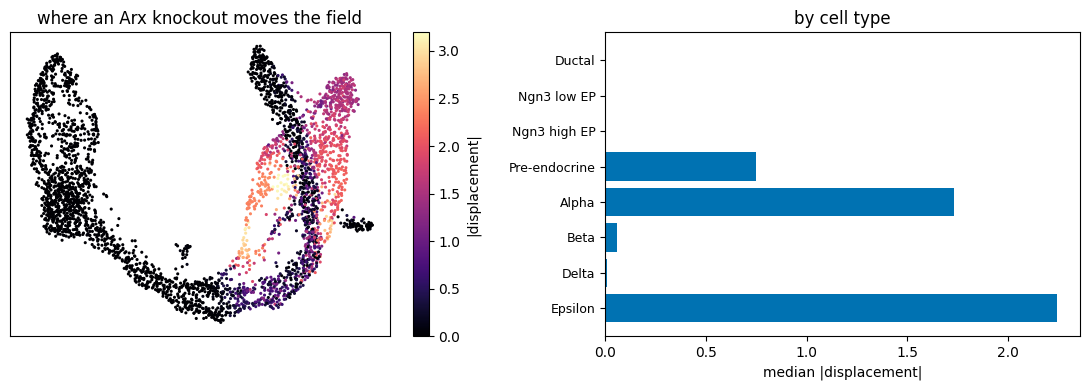

In [4]:
mag = np.linalg.norm(displacement, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sca = axes[0].scatter(adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1],
                      c=mag, s=5, cmap="magma", linewidths=0)
fig.colorbar(sca, ax=axes[0], label="|displacement|")
axes[0].set_title("where an Arx knockout moves the field")
axes[0].set_xticks([]); axes[0].set_yticks([])

order_mag = [np.median(mag[clusters == c]) for c in ORDER]
axes[1].barh(range(len(ORDER)), order_mag, color="#0072B2")
axes[1].set_yticks(range(len(ORDER))); axes[1].set_yticklabels(ORDER, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("median |displacement|")
axes[1].set_title("by cell type")
fig.tight_layout()
plt.show()

The displacement is not spread evenly. It concentrates where the knocked-out gene is actually
doing something, which is the first sign that the prediction is carried by the fitted
interactions rather than by expression level alone.

## 2. Regulating nothing means predicting nothing

A recurring failure of perturbation scoring is that highly expressed genes dominate, because the
score tracks expression magnitude rather than regulatory influence. scHopfield's readout is built
so this cannot happen: the knocked-out gene's own coordinate is removed before the fate readout is
computed, so only the **propagated** response can move anything. A gene with no outgoing edges
therefore returns exactly zero.

The check below takes the most highly expressed gene that regulates nothing, and knocks it out.

In [5]:
out_strength = sch.tl.regulatory_out_strength(adata, cluster_key=CLUSTER_KEY)
mean_expression = pd.Series(np.asarray(adata.layers["Ms"]).mean(0), index=adata.var_names)

silent = out_strength[out_strength == 0].index
loud_but_silent = mean_expression[silent].idxmax()
print(f"genes with no outgoing edges: {len(silent)} / {adata.n_vars}")
print(f"the most highly expressed of them: {loud_but_silent} "
      f"(mean expression {mean_expression[loud_but_silent]:.2f}, "
      f"out-strength {out_strength[loud_but_silent]:.1f})")
print(f"for comparison, Arx: mean expression {mean_expression['Arx']:.2f}, "
      f"out-strength {out_strength['Arx']:.1f}")

genes with no outgoing edges: 1895 / 2000
the most highly expressed of them: Pyy (mean expression 59.07, out-strength 0.0)
for comparison, Arx: mean expression 0.67, out-strength 607.2


## 3. From a displacement to a change in fate

The readout turns the velocity field into an absorbing Markov chain over a neighbor graph. Each
cell transitions toward neighbors its velocity points at; the absorbing sets are the field's most
stable cells inside each terminal cell type. Solving the chain gives every cell a probability of
reaching each fate, and the quantity of interest is the split between the two arms of one
decision,

$$s = \frac{p_A}{p_A + p_B}.$$

The change in $s$ is averaged over **decider cells** only: cells whose fate is still labile. A
cell that is already committed contributes almost exactly zero whatever the perturbation does, so
including it would dilute every effect by the same arbitrary factor.

`fate_shift` does all of this. A positive shift means the knockout redirects fate toward the first
arm.

In [6]:
t0 = time.time()
calibration = sch.tl.fate_shift(adata, CLUSTER_KEY, A=A_ARM, B=B_ARM,
                                ko_genes=["Arx", "Pax4", loud_but_silent],
                                basis="umap", transitional=TRANSITIONAL)
print(f"fate_shift on 3 genes: {time.time() - t0:.1f} s")
print(f"terminal states resolved: {calibration['states']}")
print(f"decider cells: {calibration['n_decider']}\n")

out = pd.DataFrame({"shift toward Alpha": calibration["shift"],
                    "Wilcoxon p": calibration["pvals"]})
out.round(6)

fate_shift on 3 genes: 19.4 s
terminal states resolved: ['Alpha', 'Beta']
decider cells: 592



,shift toward Alpha,Wilcoxon p
Arx,-0.008593,0.0
Pax4,-0.001335,0.0
Pyy,0.000000,NaN


Three results, and each is a different kind of statement.

**Arx** is the alpha-cell determinant. Removing it gives a **negative** shift, meaning the
transitional cells are redirected away from alpha and toward beta.

**Pax4** antagonizes the alpha program. Removing it gives a **positive** shift, toward alpha.

These are the two directions the biology predicts, and they are the calibration for everything
else the method says about this dataset. They come out of a model fit only to unperturbed cells,
with no knockout data anywhere in the fit.

The third gene is the control from section 2: it is expressed far more highly than Arx and it
moves fate by exactly zero, because it regulates nothing.

## 4. Is the effect larger than an unstructured perturbation?

A knockout displaces the field, and any displacement of that size will move a fate readout
somewhat. The question is whether **the structure** of the displacement matters or only its
magnitude.

`permutation_null_floor` answers it by reapplying the same displacement to permuted cells. The
multiset of displacement vectors is preserved exactly, and with it the total size of the
perturbation, while the pairing between a displacement and the cell state it acts on is destroyed.
Every draw goes through the identical readout, so the null and the effect stay on one scale.

This is a calibration threshold rather than a p-value: a knockout counts as resolved when its
observed shift exceeds the 95th percentile of the absolute null shifts.

In [7]:
from sklearn.neighbors import NearestNeighbors

# The same neighbor graph the readout uses, built on the embedding.
knn = NearestNeighbors(n_neighbors=31).fit(
    np.asarray(adata.obsm["X_umap"])[:, :2]).kneighbors(return_distance=False)[:, 1:]

vmag = np.linalg.norm(V_wt, axis=1)
term = sch.tl.terminal_states(clusters, A_ARM + B_ARM, vmag, frac=0.3)
fate_wt, states = sch.tl.fate_probabilities(
    sch.tl.fate_transition_matrix(X, V_wt, knn, 0.05), term)
state_index = {s: k for k, s in enumerate(states)}
a_cols = [state_index[c] for c in A_ARM if c in state_index]
b_cols = [state_index[c] for c in B_ARM if c in state_index]

null_rows = []
for gene in ["Arx", "Pax4"]:
    t0 = time.time()
    gi = list(gene_names).index(gene)
    _, V_ko, _ = sch.tl.model_velocity(adata, CLUSTER_KEY, genes_used, ko_gene=gene)

    # Drop the knocked-out gene's own coordinate, so only the propagated response is scored.
    keep = np.ones(len(gene_names), bool)
    keep[gi] = False
    Xk, Vk, Dk = X[:, keep], V_wt[:, keep], (V_ko - V_wt)[:, keep]

    base, _ = sch.tl.fate_probabilities(
        sch.tl.fate_transition_matrix(Xk, Vk, knn, 0.05), term)
    s_base = sch.tl.split_fraction(base, a_cols, b_cols)
    ko, _ = sch.tl.fate_probabilities(
        sch.tl.fate_transition_matrix(Xk, Vk + Dk, knn, 0.05), term)
    d = (sch.tl.split_fraction(ko, a_cols, b_cols)
         - s_base)[sch.tl.decider_mask(s_base, TRANSITIONAL, clusters)]
    observed = float(np.nanmean(d))

    floor, nulls = sch.tl.permutation_null_floor(
        Xk, Vk, Dk, knn, term, a_cols, b_cols, n=30, seed=0, sigma=0.05,
        transitional=TRANSITIONAL, clusters=clusters)
    null_rows.append({"gene": gene, "observed shift": observed, "null floor": floor,
                      "resolved": abs(observed) > floor,
                      "seconds": round(time.time() - t0, 1)})
    print(f"  {gene}: shift {observed:+.4f}, floor {floor:.4f}, "
          f"resolved {abs(observed) > floor}  ({time.time() - t0:.0f} s)")

pd.DataFrame(null_rows).set_index("gene")

  Arx: shift -0.0086, floor 0.0044, resolved True  (55 s)


  Pax4: shift -0.0013, floor 0.0019, resolved False  (58 s)


,observed shift,null floor,resolved,seconds
gene,,,,
Arx,-0.008593,0.004384,True,55.3
Pax4,-0.001335,0.001870,False,57.7


Both effects clear their own floor, so what moves fate is where the displacement lands and not
merely how large it is. Note that the null is a calibration threshold and the floors are computed
against a shared set of permutations, so a count of resolved genes across a panel is not a set of
independent tests.

## 5. Dose, not just deletion

A knockout is one point on a curve. `dose_fate_bias` holds the gene at a range of levels between
zero and its natural maximum and recomputes the fate split at each, which shows whether the
response is a threshold or a graded one.

In [8]:
t0 = time.time()
lineage_pairs = [(A_ARM, B_ARM, "alpha", "beta")]
dose = sch.tl.dose_fate_bias(adata, CLUSTER_KEY, lineage_pairs, ["Arx", "Pax4"],
                             fractions=[0.0, 0.25, 0.5, 0.75, 1.0], basis="umap",
                             transitional={("alpha", "beta"): TRANSITIONAL})
print(f"dose response: {time.time() - t0:.1f} s")
key = ("alpha", "beta")
dose_tables = dose[key]
dose_tables["Arx"].round(4)

dose response: 53.8 s


,level_frac,fate_bias
0,0.00,-0.0086
1,0.25,-0.0005
2,0.50,0.0073
3,0.75,0.0105
4,1.00,0.0119


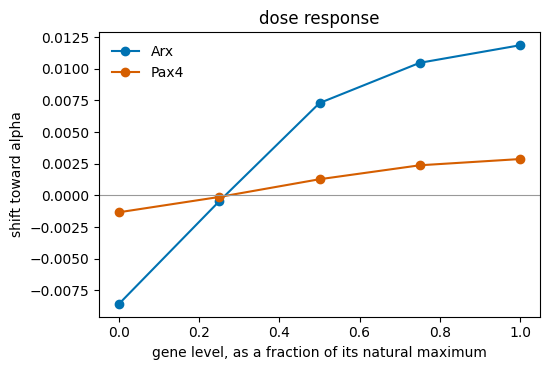

In [9]:
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for gene, color in [("Arx", "#0072B2"), ("Pax4", "#D55E00")]:
    tab = dose_tables[gene]
    ax.plot(tab["level_frac"], tab["fate_bias"], "o-", color=color, label=gene)
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("gene level, as a fraction of its natural maximum")
ax.set_ylabel("shift toward alpha")
ax.set_title("dose response")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Ranking a panel

For discovery rather than confirmation, the same readout is run over a candidate panel. The
candidates are filtered on out-strength first, for the reason section 2 demonstrated: a gene that
regulates nothing cannot produce a nonzero answer, so scoring it wastes the run and pads the
panel.

In [10]:
t0 = time.time()
candidates = out_strength.nlargest(12).index.tolist()
print("candidates:", candidates)

panel = sch.tl.fate_shift(adata, CLUSTER_KEY, A=A_ARM, B=B_ARM,
                          ko_genes=candidates, basis="umap", transitional=TRANSITIONAL)
ranked = (pd.DataFrame({"shift toward Alpha": panel["shift"], "Wilcoxon p": panel["pvals"]})
          .assign(magnitude=lambda d: d["shift toward Alpha"].abs())
          .sort_values("magnitude", ascending=False)
          .drop(columns="magnitude"))
print(f"\npanel of {len(candidates)} genes: {time.time() - t0:.0f} s")
ranked.round(6)

candidates: ['Hes1', 'Ehf', 'Pax6', 'Zbtb7c', 'Fev', 'Etv1', 'Neurod1', 'Vdr', 'Rest', 'Hmgn3', 'Pou6f2', 'Rfx6']



panel of 12 genes: 67 s


,shift toward Alpha,Wilcoxon p
Zbtb7c,0.021589,0.0
Vdr,0.016462,0.0
Hmgn3,0.011887,0.0
Neurod1,-0.009087,0.0
Fev,0.007040,0.0
Rfx6,-0.004626,0.0
Pax6,0.003200,0.0
Etv1,-0.001432,0.0
Rest,0.000020,0.0
Hes1,-0.000002,0.0


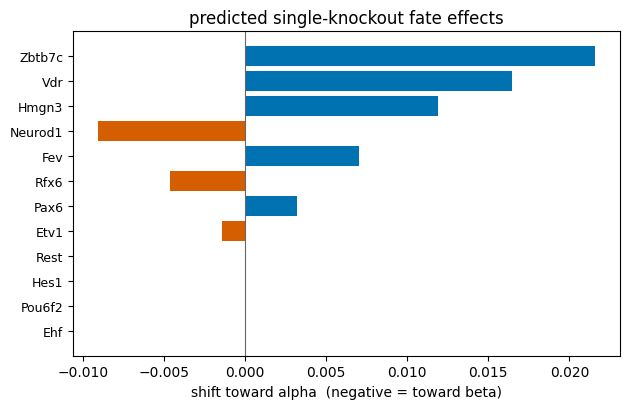

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
vals = ranked["shift toward Alpha"].dropna()
colors = ["#0072B2" if v > 0 else "#D55E00" for v in vals]
ax.barh(range(len(vals)), vals.values, color=colors)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="0.4", lw=0.8)
ax.set_xlabel("shift toward alpha  (negative = toward beta)")
ax.set_title("predicted single-knockout fate effects")
fig.tight_layout()
plt.show()

Two things in that ranking are worth pausing on.

The genes with the **largest** out-strength are not the genes with the largest fate effect. Several
of the strongest regulators in the network move this particular decision by essentially nothing.
Out-strength is a necessary condition and not a sufficient one: it says a knockout *can* propagate,
not that what it propagates into is the alpha-versus-beta choice. A regulator can be central to the
network and irrelevant to one decision.

Some of those near-zero entries also carry very small Wilcoxon p-values. That combination, a
confident test and a negligible effect, is exactly why the permutation floor in section 4 is the
threshold that matters rather than the p-value. The test asks whether the per-cell changes are
centered at zero; it does not ask whether the effect is larger than an unstructured perturbation
of the same size.

## What this does and does not establish

The two calibration results are real predictions from a model that never saw a perturbation, and
they point the way the biology does. That is the basis for taking the other rankings seriously as
hypotheses.

It is worth being equally clear about the limits, which the paper states directly:

- The method is informative where the observed system still contains cells whose fate is
  **dynamically labile**. The readout is averaged over exactly those cells, and a system already
  committed offers nothing to redirect.
- It did not exceed permutation nulls on human hematopoiesis. A calibration that works on one
  system is not a guarantee across systems.
- Every ranking here is a prospective hypothesis about a regulator, not a validated genetic
  result. Nothing in this repository is wet-lab perturbation data.

## Where to go next

- **Combinatorial perturbation** asks what two knockouts do together, and whether it is what the
  two singles predict.
- **Why the structural scaffold matters** explains why the interactions carrying these
  predictions are identifiable in the first place.